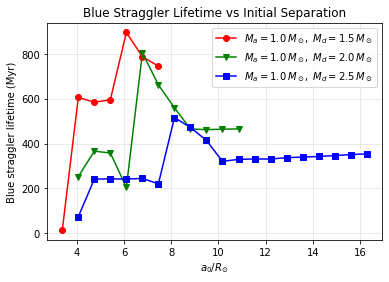

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d


"""
Blue Straggler Lifetime vs Initial Separation

This script computes the lifetime of blue stragglers for different
initial binary separations and donor masses using BSE.

Author: Emilie Desrochers Karlsson
"""


# -------------------------------
# SETTINGS
# -------------------------------

plt.rcParams['text.usetex'] = False  # avoid LaTeX dependency
BS_THRESHOLD = 1.01  # mass threshold for blue straggler


# -------------------------------
# FUNCTIONS
# -------------------------------

def run_bse(m1, m2, separation, var4):
    """
    Runs BSE simulation for a binary system.

    Returns:
        time, mass star 1, mass star 2, stellar phase star 1, stellar phase star 2 arrays
    """
    with open("binary.in", "r") as f:
        lines = f.readlines()

    maxtime = 90000
    total_mass = m1 + m2
    period = np.sqrt((separation / 214.9)**3 * (1 / total_mass)) * 365

    lines[0] = "{} {} {} {} {} {} {} {}\n".format(
        m1, m2, maxtime, period, 1, 1, 0.02, var4
    )

    with open("binary.in", "w") as f:
        f.writelines(lines)

    os.system("./bse")

    data = np.loadtxt("binary.dat")
    return np.stack(data, axis=-1)


def main_sequence_lifetime(m1):
    """
    Computes main-sequence lifetime for a star using BSE.
    """
    data = run_bse(m1, 0, 0, 0.5)

    time = data[0]
    kw = data[1]

    ms_indices = [i for i in range(len(kw)) if kw[i] == 1] 
    return time[ms_indices[-1]]


def compute_turnoff_mass():
    """
    Computes turnoff mass as a function of time.
    """
    masses = np.linspace(0.8, 10, 100)
    lifetimes = [main_sequence_lifetime(m) for m in masses]

    return interp1d(lifetimes, masses, kind="cubic", fill_value="extrapolate")


def blue_straggler_lifetime(m1, m2, separation, turnoff_mass):
    """
    Computes lifetime of blue straggler phase.
    """
    data = run_bse(m1, m2, separation, var4=0.0)

    time = data[0]
    kw1, kw2 = data[1], data[2]  #stellar phase (1=main sequence)
    mass1, mass2 = data[3], data[4]

    bs_times = []

    for i in range(len(time)):
        if kw1[i] == 1 and mass1[i] > BS_THRESHOLD * turnoff_mass(time[i]):
            bs_times.append(time[i])

        if kw2[i] == 1 and mass2[i] > BS_THRESHOLD * turnoff_mass(time[i]):
            bs_times.append(time[i])

    if not bs_times:
        return 0

    return abs(bs_times[0] - bs_times[-1])


def run_simulation(m1, m2, separations, turnoff_mass):
    """
    Runs BS lifetime calculation over a range of initial semi major axes
    """
    lifetimes = [blue_straggler_lifetime(m1, m2, a, turnoff_mass)
                 for a in separations]

    # filter valid results
    a_filtered = []
    lifetime_filtered = []

    for i in range(len(lifetimes)):
        if lifetimes[i] > 0:
            a_filtered.append(separations[i])
            lifetime_filtered.append(lifetimes[i])

    return a_filtered, lifetime_filtered


# -------------------------------
# MAIN SIMULATION
# -------------------------------

if __name__ == "__main__":

    turnoff_mass = compute_turnoff_mass()
    separations = np.linspace(0, 40, 60)


    # mass configurations (accretor, donor)
    configs = [
        (1.0, 1.5, 'red', 'o'),
        (1.0, 2.0, 'green', 'v'),
        (1.0, 2.5, 'blue', 's')
    ]

    plt.figure()
    ax = plt.gca()

    for m1, m2, color, marker in configs:
        a_vals, lifetimes = run_simulation(m1, m2, separations, turnoff_mass)

        plt.plot(a_vals, lifetimes,
                 color=color,
                 marker=marker,
                 linestyle='-',
                 label=fr'$M_a={m1}\,M_\odot,\; M_d={m2}\,M_\odot$')

    plt.xlabel(r'$a_0 / R_{\odot}$')
    plt.ylabel('Blue straggler lifetime (Myr)')

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.title('Blue Straggler Lifetime vs Initial Separation')

    plt.show()